In [1]:
import cv2, matplotlib.pyplot as plt, numpy as np

In [49]:
boxes = np.array([
    [30, 30, 190, 190],
    [100, 100, 210, 210],
    [200, 200, 350, 350],
    [250, 250, 370, 370]
])

# scores for boxes
scores = np.array([0.9, 0.3, 0.2, 0.6]) # only highest score boxes will be kept; 0, 3  index are highest

# non max suppression
def simple_nms(boxes, scores, top_n=2):
    indices = np.argsort(scores)[::-1]
    return indices[:top_n] # keep top 2 only

keep_indices = simple_nms(boxes, scores, 2)
print("kept boxes: ", keep_indices)

kept boxes:  [0 3]


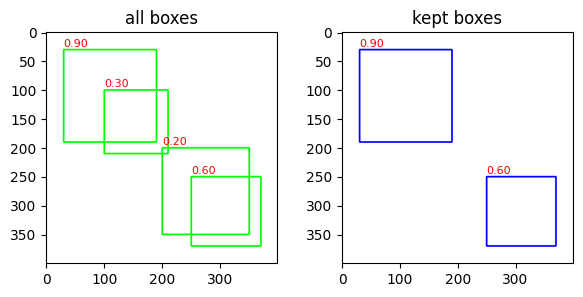

In [50]:
# visualize boxes, 
# all boxes on canvas
canvas = 255 * np.ones((400, 400, 3), dtype=np.uint8)
for box in (boxes):
    cv2.rectangle(canvas, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)

# nms kept boxes on canvas
canvas2 = 255 * np.ones((400, 400, 3), dtype=np.uint8)
for index in (keep_indices):
    box = boxes[index]
    cv2.rectangle(canvas2, (box[0], box[1]), (box[2], box[3]), (0, 0, 255), 2)

plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.imshow(canvas)
for i, box in enumerate(boxes):
    plt.text(box[0], box[1]-5, f"{scores[i]:.2f}", color='red', fontsize=8) # show score on box
plt.title("all boxes")
plt.subplot(1, 2, 2)
plt.imshow(canvas2)
plt.title("kept boxes")
for idx in keep_indices:
    box = boxes[idx]
    plt.text(box[0], box[1]-5, f"{scores[idx]:.2f}", color='red', fontsize=8)